In [14]:
import sys
sys.path.append("../../")


PARAM SET: baseline
Run 1 | seed=42
Epoch     0 | Loss: 384794752.000000 | Data: 375781472.000000 | ODE: 2642889.250000
Params: β=0.3000, γ=0.0600, μ=0.0030
---
Epoch  1000 | Loss: 24385970.000000 | Data: 20458664.000000 | ODE: 3923020.750000
Params: β=0.3000, γ=0.0600, μ=0.0030
---
Epoch  2000 | Loss: 3658176.250000 | Data: 1647036.875000 | ODE: 2010134.625000
Params: β=0.3000, γ=0.0600, μ=0.0030
---
Epoch  3000 | Loss: 1219427.875000 | Data: 304769.750000 | ODE: 913576.375000
Params: β=0.3000, γ=0.0600, μ=0.0030
---
Epoch  4000 | Loss: 749359.250000 | Data: 283458.875000 | ODE: 464898.875000
Params: β=0.3000, γ=0.0600, μ=0.0030
---
Epoch  5000 | Loss: 328904.562500 | Data: 49399.160156 | ODE: 278505.218750
Params: β=0.3000, γ=0.0600, μ=0.0030
---
Epoch  6000 | Loss: 248220.328125 | Data: 31183.822266 | ODE: 216036.343750
Params: β=0.3000, γ=0.0600, μ=0.0030
---
Epoch  7000 | Loss: 209683.343750 | Data: 23791.703125 | ODE: 184891.625000
Params: β=0.3000, γ=0.0600, μ=0.0030
---
Epoch 

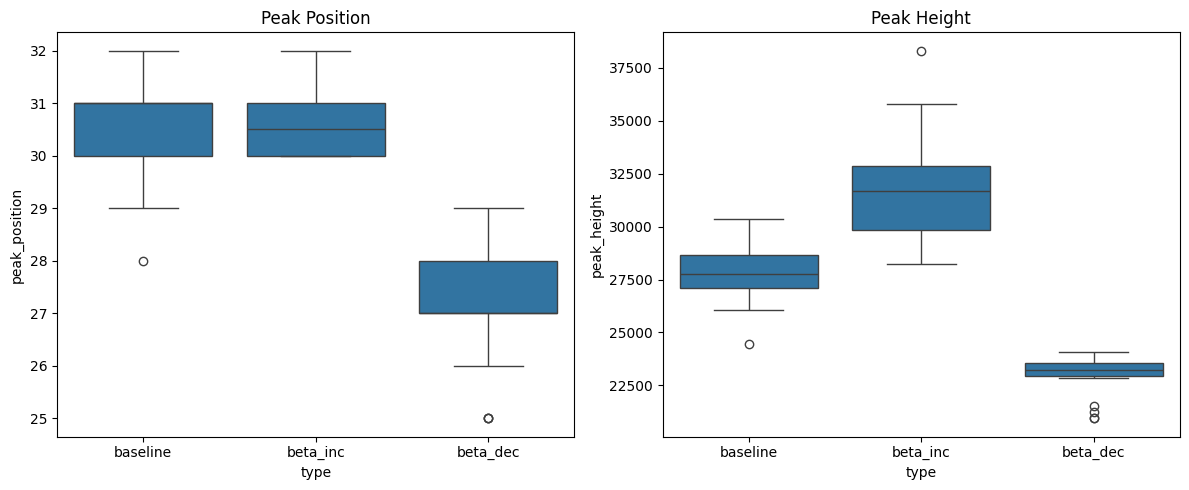


Results saved to: ./experiment_results\peak_results_synthetic.csv
Statistics saved to: ./experiment_results\statistics_synthetic.txt


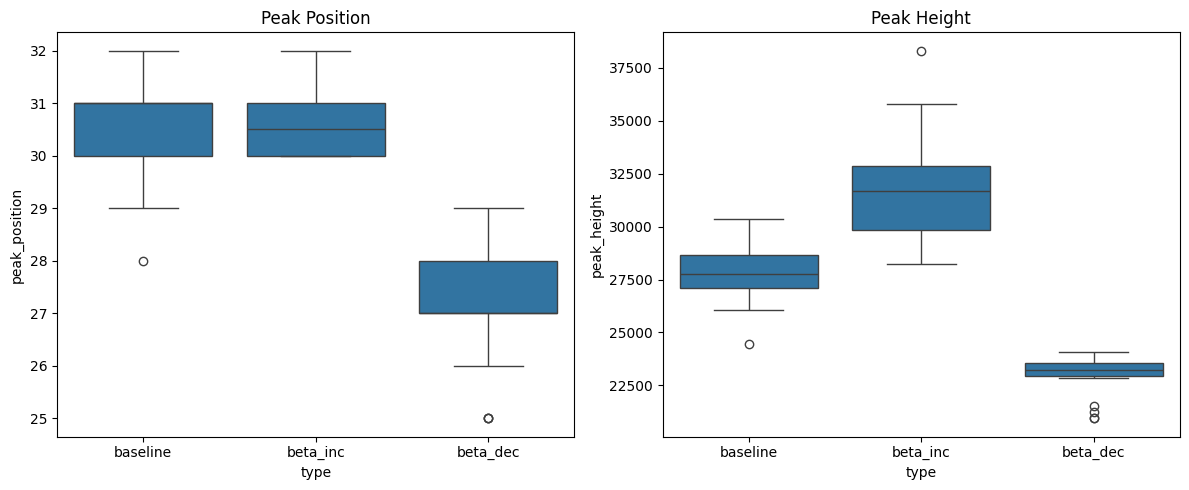

Plot saved to: ./experiment_results\peak_boxplot_synthetic.png


In [15]:
import torch
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from NEW_PINN_LLM_SUR.LLM_epiparam_generator.agents.PINN_const import EINN_PINN

# ============================================
# Seed
# ============================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================
# Данные
# ============================================
# covid_cases = pd.read_csv('../real_datasets/covid-19_Kouprianov.csv')
covid_cases = pd.read_csv('../synthetic_datasets/03_beta_baseline_constant.csv')

S = covid_cases['S'].values
I = covid_cases['I'].values
D = covid_cases['D'].values
R = covid_cases['R'].values

timesteps = np.arange(len(S)).astype(float)

train_size = 25
population = S[0] + I[0] + R[0] + D[0]


# ============================================
# Параметры
# ============================================
baseline_params = {
    "beta": 0.3,
    "gamma": 0.06,
    "mu": 0.003
}

new_params = {
    "beta": 0.1,
    "gamma": 0.06,
    "mu": 0.003
}

new_params_2 = {
    "beta": 0.5,
    "gamma": 0.06,
    "mu": 0.003
}

param_sets = {
    "baseline": baseline_params,
    "beta_inc": new_params_2,
    "beta_dec": new_params,
}


# ============================================
# Эксперимент
# ============================================

n_runs = 20

results = []

for label, params in param_sets.items():

    print("\n" + "="*60)
    print(f"PARAM SET: {label}")
    print("="*60)

    for run in range(n_runs):

        seed = 42 + run
        print(f"Run {run+1} | seed={seed}")

        set_seed(seed)

        model = EINN_PINN(
            t=timesteps,
            S_data=S,
            I_data=I,
            R_data=R,
            D_data=D,
            population=population,
            train_size=train_size,
            init_params=params,
            device='cuda'
        )
        if label == '1':
            model.train_model(
            n_epoch=10,
            lambda_data=1.0,
            lambda_ode=1.0,
            lambda_ic=0.1,
            lambda_bc=0.1
            )
        else:
            model.train_model(
                n_epoch=10_000,
                lambda_data=1.0,
                lambda_ode=1.0,
                lambda_ic=0.1,
                lambda_bc=0.1
            )

        S_pred, I_pred, R_pred, D_pred = model.predict(timesteps)

        I_pred = I_pred.numpy()

        peak_pos = np.argmax(I_pred)
        peak_height = np.max(I_pred)

        results.append({
            "type": label,
            "seed": seed,
            "peak_position": peak_pos,
            "peak_height": peak_height
        })

        print(f"Peak pos = {peak_pos}")
        print(f"Peak height = {peak_height:.2f}")


# ============================================
# DataFrame
# ============================================

results_df = pd.DataFrame(results)

print("\n")
print(results_df)


# ============================================
# Статистика
# ============================================

print("\nSTATISTICS")
print("="*50)

print("\nPeak Position")
print(results_df.groupby("type")["peak_position"].describe())

print("\nPeak Height")
print(results_df.groupby("type")["peak_height"].describe())


# ============================================
# Boxplot
# ============================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=results_df, x="type", y="peak_position")
plt.title("Peak Position")

plt.subplot(1,2,2)
sns.boxplot(data=results_df, x="type", y="peak_height")
plt.title("Peak Height")

plt.tight_layout()
plt.show()

# ============================================
# Сохранение результатов
# ============================================

import os

output_dir = "./experiment_results"
os.makedirs(output_dir, exist_ok=True)

# CSV
csv_path = os.path.join(output_dir, "peak_results_synthetic.csv")
results_df.to_csv(csv_path, index=False)

print(f"\nResults saved to: {csv_path}")


# ============================================
# Сохранение статистики в TXT
# ============================================

stats_path = os.path.join(output_dir, "statistics_synthetic.txt")

with open(stats_path, "w") as f:
    f.write("Peak Position\n")
    f.write("="*50 + "\n")
    f.write(str(results_df.groupby("type")["peak_position"].describe()))
    
    f.write("\n\nPeak Height\n")
    f.write("="*50 + "\n")
    f.write(str(results_df.groupby("type")["peak_height"].describe()))

print(f"Statistics saved to: {stats_path}")


# ============================================
# Boxplot + сохранение
# ============================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=results_df, x="type", y="peak_position")
plt.title("Peak Position")

plt.subplot(1,2,2)
sns.boxplot(data=results_df, x="type", y="peak_height")
plt.title("Peak Height")

plt.tight_layout()

plot_path = os.path.join(output_dir, "peak_boxplot_synthetic.png")
plt.savefig(plot_path, dpi=300)

plt.show()

print(f"Plot saved to: {plot_path}")

In [17]:
import pandas as pd
import numpy as np
from scipy import stats

# Загрузка данных
df = pd.read_csv("experiment_results/peak_results_synthetic.csv")

# Разделение групп
baseline = df[df["type"] == "baseline"]
new = df[df["type"] == "beta_inc"]

# ============================================
# Функция Cohen's d
# ============================================
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_std


# ============================================
# Анализ Peak Height
# ============================================

print("\n" + "="*60)
print("PEAK HEIGHT ANALYSIS")
print("="*60)

baseline_height = baseline["peak_height"]
new_height = new["peak_height"]

# t-test
t_stat, t_p = stats.ttest_ind(baseline_height, new_height)

# Mann Whitney
u_stat, u_p = stats.mannwhitneyu(baseline_height, new_height)

# effect size
d = cohens_d(baseline_height, new_height)

print(f"Baseline mean: {baseline_height.mean():.2f}")
print(f"New mean: {new_height.mean():.2f}")
print()

print(f"T-test p-value: {t_p:.6f}")
print(f"Mann-Whitney p-value: {u_p:.6f}")
print(f"Cohen's d: {d:.4f}")


# ============================================
# Анализ Peak Position
# ============================================

print("\n" + "="*60)
print("PEAK POSITION ANALYSIS")
print("="*60)

baseline_pos = baseline["peak_position"]
new_pos = new["peak_position"]

t_stat, t_p = stats.ttest_ind(baseline_pos, new_pos)
u_stat, u_p = stats.mannwhitneyu(baseline_pos, new_pos)
d = cohens_d(baseline_pos, new_pos)

print(f"Baseline mean: {baseline_pos.mean():.2f}")
print(f"New mean: {new_pos.mean():.2f}")
print()

print(f"T-test p-value: {t_p:.6f}")
print(f"Mann-Whitney p-value: {u_p:.6f}")
print(f"Cohen's d: {d:.4f}")


# ============================================
# Интерпретация
# ============================================

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)

alpha = 0.05

print("Peak Height:")
if t_p < alpha:
    print("Statistically significant difference")
else:
    print("No statistically significant difference")


PEAK HEIGHT ANALYSIS
Baseline mean: 27804.27
New mean: 31670.36

T-test p-value: 0.000001
Mann-Whitney p-value: 0.000004
Cohen's d: -1.8384

PEAK POSITION ANALYSIS
Baseline mean: 30.45
New mean: 30.60

T-test p-value: 0.552068
Mann-Whitney p-value: 0.870449
Cohen's d: -0.1897

INTERPRETATION
Peak Height:
No statistically significant difference
